In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the datasets
hq_t2 = pd.read_csv('hq_IQM_t2.csv')
hq_adc = pd.read_csv('hq_IQM_adc.csv')

# Ensure 'Participant' column is consistent by removing suffixes if needed
hq_t2['Participant'] = hq_t2['Participant'].astype(str).str.replace(r'_t2$', '', regex=True)
hq_adc['Participant'] = hq_adc['Participant'].astype(str).str.replace(r'_adc$', '', regex=True)

# Merge the dataframes on 'Participant' column
merged_df = pd.merge(hq_t2, hq_adc, on='Participant', how='inner')

# Drop columns with more than 50% missing values
threshold = 0.5 * len(merged_df)  # 50% of rows
merged_df = merged_df.dropna(thresh=threshold, axis=1)

# Remove outliers using Z-score method (only for numeric columns)
#numeric_cols = merged_df.select_dtypes(include=[np.number])  # Select numeric columns
#z_scores = np.abs(stats.zscore(numeric_cols, nan_policy='omit'))  # Compute Z-scores
#merged_df = merged_df[(z_scores < 3).all(axis=1)]  # Keep rows where all Z-scores are within 3



In [3]:
merged_df

,Participant,VRX_x,VRY_x,VRZ_x,ROW_x,COL_x,NUM_x,MEAN_x,RNG_x,VAR_x,...,SNR3_y,SNR4_y,SNR6_y,SNR7_y,SNR8_y,CNR_y,CVP_y,CJV_y,EFC_y,FBER_y
0,1,0.364583,0.364583,3.0,384,384,30,231.924257,2013.633333,28807.46139,...,2.412865,2.157293e+11,1.343161,0.574797,1.283659,2.157294e+08,0.619338,1.648813,2.721420,4.368667e+08
1,10,0.364583,0.364583,3.0,384,384,30,240.681782,1539.533333,25529.30844,...,4.153842,4.519600e+11,1.723579,0.556776,1.574680,4.519600e+08,0.508291,1.802852,2.407845,3.024334e+08
2,10376639,0.625000,0.625000,3.5,320,320,26,266.920404,933.115385,30758.17965,...,11.485236,8.214564e+11,1.054588,0.955944,1.735203,8.214564e+08,0.273704,1.327523,2.997652,0.000000e+00
3,11,0.437500,0.437500,3.0,320,320,30,218.826300,1285.733333,22445.67640,...,12.020620,4.654613e+11,1.556171,0.472390,1.195440,4.654614e+08,0.450351,1.867078,2.576936,2.386000e+08
4,12487_29542496,0.351600,0.351600,3.0,512,512,38,423.842670,1971.789474,84133.40134,...,0.000000,0.000000e+00,1.701559,1.233902,3.009561,7.515441e-01,0.000000,0.590900,2.611545,1.313115e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,UH_0005621,0.714286,0.714286,3.0,224,224,44,500.515900,1489.340909,79689.02086,...,4.975277,4.332236e+11,1.141518,0.857008,1.732083,4.332236e+08,0.267221,1.356106,3.219323,1.405591e+10
183,UH_0005651,0.714286,0.714286,3.0,224,224,44,348.213368,1077.113636,37534.05554,...,0.000000,0.000000e+00,1.045822,0.351565,1.154577,-5.538043e-01,0.000000,1.722098,3.145948,2.046534e+09
184,UH_0005681,0.714286,0.714286,3.0,224,224,44,429.283306,1335.704545,60032.89569,...,0.000000,0.000000e+00,0.971986,0.470636,1.460183,-3.366665e-01,0.000000,1.273112,3.264900,1.594248e+10
185,UH_0005701,0.714286,0.714286,3.0,224,224,44,463.418059,1308.545455,57187.25784,...,0.000000,0.000000e+00,0.984236,0.563479,1.560634,-3.520496e-01,0.000000,1.298937,3.386927,1.675412e+10


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


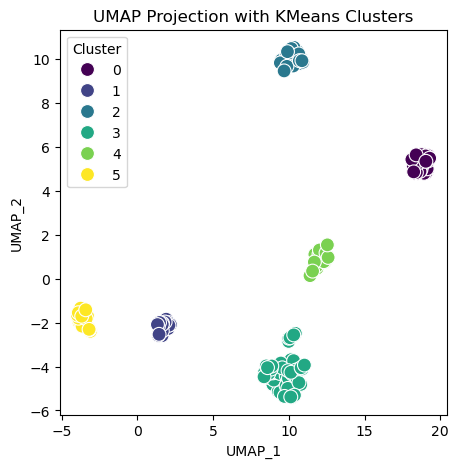

        Participant  Cluster
0                 1        3
1                10        3
2          10376639        4
3                11        3
4    12487_29542496        0
..              ...      ...
182      UH_0005621        5
183      UH_0005651        5
184      UH_0005681        5
185      UH_0005701        5
186      UH_0005741        5

[187 rows x 2 columns]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans

# Assuming merged_df is already loaded

# Remove 'Participant' column if it exists
if 'Participant' in merged_df.columns:
    merged_data = merged_df.drop(columns=['Participant'])
else:
    merged_data = merged_df.copy()

merged_data = merged_data.fillna(merged_data.mean())

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(merged_data)

# Apply UMAP for dimensionality reduction
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_embedding = umap_reducer.fit_transform(scaled_features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42)  # Adjust the number of clusters as needed
kmeans_labels = kmeans.fit_predict(umap_embedding)

# Add the cluster labels and UMAP coordinates back to the original data
merged_data['Cluster'] = kmeans_labels
merged_data['UMAP_1'] = umap_embedding[:, 0]
merged_data['UMAP_2'] = umap_embedding[:, 1]

# If the original 'Participant' column exists, map cluster assignments back to participants
if 'Participant' in merged_df.columns:
    merged_data['Participant'] = merged_df['Participant']

# Visualize UMAP results with KMeans clusters
plt.figure(figsize=(5, 5))
sns.scatterplot(x='UMAP_1', y='UMAP_2', hue='Cluster', palette='viridis', data=merged_data, s=100)
plt.title('UMAP Projection with KMeans Clusters')
plt.legend(title='Cluster')
plt.show()

# Display patients and their assigned clusters
patients_clusters = merged_data[['Participant', 'Cluster']] if 'Participant' in merged_data.columns else merged_data[['Cluster']]
print(patients_clusters)


In [9]:
# Save the patients and their assigned clusters to an Excel file
patients_clusters = merged_data[['Participant', 'Cluster']] if 'Participant' in merged_data.columns else merged_data[['Cluster']]
file_path = "patients_clusters.xlsx"
patients_clusters.to_excel(file_path, index=False)




In [ ]:
pwd